# Bias Analysis

# Bias & Fairness Assessment  
### NovaCred Credit Applications Dataset (Cleaned)

This notebook evaluates **fairness risks in credit approvals** using the **cleaned dataset** produced by the Data Engineering pipeline (`01-data-quality.ipynb`).

We focus on patterns required in the project brief:
- **Gender disparate impact (DI)**
- **Age discrimination patterns**
- **ZIP code as a proxy feature**
- **Interaction effects (age × gender)**

**Important:** We intentionally do **not** use direct identifiers (name/email/SSN/IP) in any analysis.

## Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## Load cleaned dataset

We load the cleaned CSV created in `01-data-quality.ipynb`.  

In [25]:
DATA_PATH = "../data/cleaned_credit_applications.csv"
df = pd.read_csv(DATA_PATH)

df.shape

(500, 43)

In [26]:
df.head(3)

,_id,applicant_info_full_name,applicant_info_email,applicant_info_ssn,applicant_info_ip_address,applicant_info_gender,applicant_info_date_of_birth,applicant_info_zip_code,financials_annual_income,financials_credit_history_months,financials_debt_to_income,financials_savings_balance,decision_loan_approved,loan_purpose,decision_interest_rate,decision_approved_amount,age_years,spend_shopping,spend_rent,spend_alcohol,spend_dining,spend_healthcare,spend_fitness,spend_entertainment,spend_insurance,spend_travel,spend_transportation,spend_utilities,spend_groceries,spend_education,spend_adult_entertainment,spend_gambling,annual_income_missing,savings_balance_missing,debt_to_income_missing,savings_balance_zero,credit_history_suspicious,dob_missing,email_missing,ssn_missing,email_valid,ssn_duplicate,needs_review
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,23.0,0.20,31212.0,False,NaN,NaN,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,True,False,False
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,51.0,0.18,17915.0,False,NaN,NaN,NaN,33.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,True,False,False
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,41.0,0.21,37909.0,True,vacation,3.7,59000.0,36.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,True,False,False


## 3) Scope: exclude direct identifiers from analysis outputs

Privacy/pseudonymization is handled in `03-privacy-demo.ipynb`.  
Here we simply avoid using direct identifiers (name/email/SSN/IP) in fairness analysis.

In [27]:
pii_cols = [
    "applicant_info_full_name",
    "applicant_info_email",
    "applicant_info_ssn",
    "applicant_info_ip_address",
]

df_bias = df.drop(columns=[c for c in pii_cols if c in df.columns]).copy()
df_bias.shape

(500, 39)

## 4) Sanity checks

We report group counts for fairness-critical fields.  
This is essential for interpreting DI and subgroup comparisons.

In [28]:
summary = pd.Series({
    "n_rows": len(df_bias),
    "approval_rate_overall": df_bias["decision_loan_approved"].mean(),
    "n_unique_zip": df_bias["applicant_info_zip_code"].nunique(),
})
summary

n_rows                   500.000
approval_rate_overall      0.584
n_unique_zip             195.000
dtype: float64

In [29]:
df_bias["applicant_info_gender"].value_counts(dropna=False)

Female    250
Male      247
NaN         3
Name: applicant_info_gender, dtype: int64

## 5) Derive age from date of birth (DOB)

The cleaned dataset contains DOB (`applicant_info_date_of_birth`).  
We derive `age_years` using the shared helper in `src/fairness_utils.py` for consistency and reproducibility.

In [30]:
import sys
sys.path.append("..")

from src.fairness_utils import add_age_years_from_dob

if "age_years" not in df_bias.columns:
    df_bias = add_age_years_from_dob(df_bias)

df_bias["age_years"].describe()

count    495.000000
mean      41.232929
std       10.944332
min       23.400000
25%       32.400000
50%       39.500000
75%       47.550000
max       67.400000
Name: age_years, dtype: float64

## 6) Method: Disparate Impact (DI)

Selection rate for a group = mean(loan_approved)

We compute:
- **DI = ApprovalRate(Female) / ApprovalRate(Male)**

**Four-fifths rule (screening heuristic):**
- Flag potential adverse impact when **DI < 0.80** (not proof of discrimination).

### DI Helper Functions

In [31]:
def selection_rate(df_in: pd.DataFrame, outcome_col: str, group_col: str) -> pd.Series:
    return df_in.groupby(group_col)[outcome_col].mean()

def disparate_impact(df_in: pd.DataFrame, outcome_col: str, group_col: str, unpriv: str, priv: str) -> float:
    rates = selection_rate(df_in, outcome_col, group_col)
    return float(rates.loc[unpriv] / rates.loc[priv])

## 7) Issue 1: Gender Disparate Impact

We report:
- group counts (Female/Male)
- approval rates
- DI (Female/Male)
- four-fifths rule flag (DI < 0.80)

In [32]:
df_gender = df_bias[df_bias["applicant_info_gender"].isin(["Female", "Male"])].copy()

gender_counts = df_gender["applicant_info_gender"].value_counts()
gender_rates = selection_rate(df_gender, "decision_loan_approved", "applicant_info_gender")
di_female_over_male = disparate_impact(df_gender, "decision_loan_approved", "applicant_info_gender", "Female", "Male")

di_flag = di_female_over_male < 0.80

gender_counts, gender_rates, di_female_over_male, di_flag

(Female    250
 Male      247
 Name: applicant_info_gender, dtype: int64,
 applicant_info_gender
 Female    0.508000
 Male      0.659919
 Name: decision_loan_approved, dtype: float64,
 0.7697914110429448,
 True)

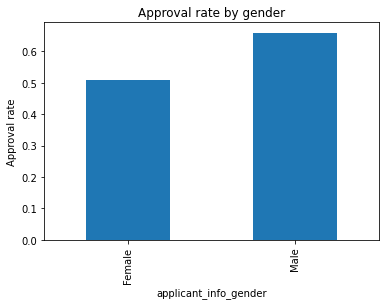

In [33]:
gender_rates.reindex(["Female", "Male"]).plot(kind="bar")
plt.ylabel("Approval rate")
plt.title("Approval rate by gender")
plt.show()

## 8) Issue 2: Age-based patterns

We bucket ages and compare approval rates across age buckets.

In [34]:
# bins = [18, 24, 34, 44, 54, 64, 100]
# labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

# df_age = df_bias.copy()
# df_age["age_bucket"] = pd.cut(df_age["age_years"], bins=bins, labels=labels)
bins = [18, 25, 35, 45, 55, 65, 200]
labels = ["18-24","25-34","35-44","45-54","55-64","65+"]

df_age = df_bias.copy()
df_age["age_bucket"] = pd.cut(df_age["age_years"], bins=bins, labels=labels, right=False)

age_counts = df_age["age_bucket"].value_counts().sort_index()
age_rates = df_age.groupby("age_bucket")["decision_loan_approved"].mean().sort_index()

age_counts, age_rates

(18-24     11
 25-34    149
 35-44    174
 45-54     92
 55-64     56
 65+       13
 Name: age_bucket, dtype: int64,
 age_bucket
 18-24    0.545455
 25-34    0.442953
 35-44    0.672414
 45-54    0.630435
 55-64    0.625000
 65+      0.538462
 Name: decision_loan_approved, dtype: float64)